In [1]:
!pip install sinabs


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
from pathlib import Path
import pandas as pd

saved_dir = Path(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\ROAD")

train_dfs = pd.read_pickle(saved_dir / "train_dfs.pkl")
test_dfs = pd.read_pickle(saved_dir / "test_dfs.pkl")

print("Reloaded train_dfs and test_dfs from saved_data/")
print("Train dfs:", len(train_dfs))
print("Test dfs:", len(test_dfs))
print("Train sizes:", [len(df) for df in train_dfs])
print("Test sizes:", [len(df) for df in test_dfs])

Reloaded train_dfs and test_dfs from saved_data/
Train dfs: 28
Test dfs: 28
Train sizes: [65010, 63341, 55726, 54014, 33464, 32452, 49539, 49505, 170718, 168763, 116716, 114204, 170841, 165956, 54322, 53784, 79703, 77806, 112684, 110737, 106590, 104997, 140756, 137805, 124842, 122961, 2393018, 850900]
Test sizes: [16252, 15835, 13931, 13503, 8365, 8113, 12384, 12376, 42679, 42190, 29178, 28550, 42710, 41488, 13580, 13446, 19925, 19451, 28171, 27684, 26647, 26249, 35189, 34451, 31210, 30740, 598254, 212724]


In [3]:
def data_to_uint8_array(data):
    if isinstance(data, bytes):
        arr = np.frombuffer(data, dtype=np.uint8)
    elif isinstance(data, str):
        s = data.strip()
        if s.startswith(("0x", "0X")):
            s = s[2:]
        if any(ch in s for ch in (" ", "-", ":", ",")):
            parts = [tok for tok in s.replace("-", " ").replace(":", " ").replace(",", " ").split() if tok]
            if all(len(tok) == 2 for tok in parts):
                arr = np.array([int(tok, 16) for tok in parts], dtype=np.uint8)
            else:
                arr = np.frombuffer(bytes.fromhex("".join(parts)), dtype=np.uint8)
        else:
            arr = np.frombuffer(bytes.fromhex(s), dtype=np.uint8)
    elif isinstance(data, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(data, dtype=np.uint8).flatten()
    elif isinstance(data, int):
        arr = np.frombuffer(data.to_bytes(8, byteorder="big", signed=False), dtype=np.uint8)
    else:
        raise TypeError(f"Unsupported Data type: {type(data)}")

    if arr.size < 8:
        arr = np.pad(arr, (0, 8 - arr.size), constant_values=0)
    elif arr.size > 8:
        arr = arr[:8]

    return arr

def sliding_windows_from_dfs(dfs, data_col="Data", window_size=32, step=2):
    windows = []
    next_values = []

    for df in dfs:
        values = df[data_col].tolist()
        byte_rows = np.stack([data_to_uint8_array(value) for value in values])

        for start in range(0, len(byte_rows) - window_size, step):
            end = start + window_size
            windows.append(byte_rows[start:end])
            next_values.append(byte_rows[end])

    return np.array(windows, dtype=np.uint8), np.array(next_values, dtype=np.uint8)

train_windows, train_next = sliding_windows_from_dfs(train_dfs, data_col="Data")
test_windows, test_next = sliding_windows_from_dfs(test_dfs, data_col="Data")

print("train_windows shape:", train_windows[0])
print("test_windows shape:", test_windows[0])

def sliding_windows_id_onehot_sums(dfs, id_onehot_col="ID_onehot", window_size=32, step=2):
    window_sums = []

    for df in dfs:
        if id_onehot_col not in df.columns:
            raise ValueError(f"Column {id_onehot_col!r} not found in DataFrame")

        id_onehot_arr = np.stack(df[id_onehot_col].tolist())

        if id_onehot_arr.ndim != 3 or id_onehot_arr.shape[1:] != (22, 8):
            raise ValueError(
                f"Expected {id_onehot_col} items to have shape (22, 8), "
                f"but got {id_onehot_arr.shape[1:]} from one DataFrame"
            )

        for start in range(0, len(id_onehot_arr) - window_size, step):
            window = id_onehot_arr[start:start + window_size]
            window_sums.append(window.sum(axis=0, dtype=np.uint16))

    return np.array(window_sums, dtype=np.uint16)


train_id_onehot_sums = sliding_windows_id_onehot_sums(train_dfs)
test_id_onehot_sums = sliding_windows_id_onehot_sums(test_dfs)

print("train_id_onehot_sums shape:", train_id_onehot_sums[0])
print("test_id_onehot_sums shape:", test_id_onehot_sums[0])

train_windows shape: [[  0   0   0   0   0  12   0  10]
 [137  47  96  11  10   1   0 128]
 [ 78 224   0   0  64   0   0   0]
 [  0 126  32  16   2   0  40 240]
 [  2 119   4  96  95   3 154   0]
 [  4  64   4 125  31 192  21  98]
 [144   0  65  31  64  63 109  96]
 [  1 244  15 199 203  31  82 154]
 [  0   6 120   0  12   2 215 208]
 [  0 242  32 252 144 124 141 217]
 [ 96   0   0   0   0   0   0   0]
 [  0   8   4  19 234  17 244 206]
 [  0  16 249 164 193  46  16 160]
 [ 32  82  86   2   8   9 118 214]
 [123  85  31 186 210  83 105  46]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  3  31   3  27   3  34   3  33]
 [ 32  19  64   0   0   1 136 128]
 [137  47  96  11  10   1   0 128]
 [  0   0   0   0   0   0  24  64]
 [  0   0   0   0   0   0   0   0]
 [ 10 119   4  96  94   3 154   0]
 [  0   6 112   0  12  66 215 208]
 [  0  16 250  36 193  46  16 160]
 [  0   0  18 128   0   0   0   0]
 [144   0  65  31  64  63  79  96]
 [  0  32  40  64   0   0 128  64]

In [4]:
# multiply non-zero entries by 8 then subtract 1; keep dtype uint16
train_id_onehot_sums = (
    (train_id_onehot_sums.astype(np.int32) * 8)
    - (train_id_onehot_sums != 0).astype(np.int32)
).astype(np.uint16)

test_id_onehot_sums = (
    (test_id_onehot_sums.astype(np.int32) * 8)
    - (test_id_onehot_sums != 0).astype(np.int32)
).astype(np.uint16)

print("train_id_onehot_sums dtype/shape:", train_id_onehot_sums.dtype, train_id_onehot_sums.shape)
print("test_id_onehot_sums dtype/shape:", test_id_onehot_sums.dtype, test_id_onehot_sums.shape)

train_id_onehot_sums dtype/shape: uint16 (2890134, 22, 8)
test_id_onehot_sums dtype/shape: uint16 (722196, 22, 8)


In [5]:
train_windows_combined = np.concatenate(
    [train_windows.astype(np.uint16), train_id_onehot_sums.astype(np.uint16)], axis=1
)
test_windows_combined = np.concatenate(
    [test_windows.astype(np.uint16), test_id_onehot_sums.astype(np.uint16)], axis=1
)

print("train_windows_combined shape:", train_windows_combined.shape)
print("test_windows_combined shape:", test_windows_combined.shape)

train_windows_combined shape: (2890134, 54, 8)
test_windows_combined shape: (722196, 54, 8)


In [6]:
def sliding_windows_attack_labels(dfs, attack_col="Attack", window_size=32, step=2):
    windows_labels = []
    
    for df in dfs:
        attacks = df[attack_col].tolist()
        
        for start in range(0, len(attacks) - window_size, step):
            window_slice = attacks[start:start + window_size]
            
            # If 'T' is in the window, label is 'T', otherwise 'R'
            label = 'T' if 'T' in window_slice else 'R'
            windows_labels.append(label)
    
    return np.array(windows_labels, dtype=object)

attack_labels_train = sliding_windows_attack_labels(train_dfs)
attack_labels_test = sliding_windows_attack_labels(test_dfs)

print("attack_labels_train shape:", attack_labels_train.shape)
print("attack_labels_test shape:", attack_labels_test.shape)
print("Sample labels (first 20):", attack_labels_train[:20])

attack_labels_train shape: (2890134,)
attack_labels_test shape: (722196,)
Sample labels (first 20): ['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R']


In [7]:
windows = train_windows_combined
windows_test = test_windows_combined
windowed_labels = attack_labels_train
windowed_labels_test = attack_labels_test

windowed_labels = np.array(windowed_labels)
attack_onehot = np.zeros((len(windowed_labels)), dtype=np.uint8)
attack_onehot[windowed_labels == 'T'] = 1

print(attack_onehot[:10])

windowed_labels_test = np.array(windowed_labels_test)

attack_onehot_test = np.zeros((len(windowed_labels_test)), dtype=np.uint8)
attack_onehot_test[windowed_labels_test == 'T'] = 1

print(attack_onehot_test[:10])

[0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0]


In [8]:
import torch
from torch.utils.data import Dataset


class CANDataset(Dataset):
    def __init__(
        self,
        windows,
        attack_onehot,
        train=True,
        is_spiking=False,
        time_window=100,
    ):
        # Convert to tensors
        self.windows = torch.as_tensor(windows, dtype=torch.float32)

        # Add channel dimension:
        # (N, H, W) -> (N, 1, H, W)
        if self.windows.ndim == 3:
            self.windows = self.windows.unsqueeze(1)

        self.labels = torch.as_tensor(attack_onehot, dtype=torch.long)

        self.is_spiking = is_spiking
        self.time_window = time_window

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):

        img = self.windows[index]
        label = self.labels[index]

        if self.is_spiking:
            # Optional normalization if inputs are not already in [0,1]
            #img = (img - img.min()) / (img.max() - img.min() + 1e-8)

            # Generate spike train
            img = (
                torch.rand(self.time_window, *img.shape) < img
            ).float()

        return img, label

In [9]:
windows

array([[[  0,   0,   0, ...,  12,   0,  10],
        [137,  47,  96, ...,   1,   0, 128],
        [ 78, 224,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[ 78, 224,   0, ...,   0,   0,   0],
        [  0, 126,  32, ...,   0,  40, 240],
        [  2, 119,   4, ...,   3, 154,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  2, 119,   4, ...,   3, 154,   0],
        [  4,  64,   4, ..., 192,  21,  98],
        [144,   0,  65, ...,  63, 109,  96],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       ...,

       [[ 32,  88,  22, ...,   9, 117, 130],
        [144,   0,  64, ...,  63,  87,  96],
        [  0,   8,   8, ...,   8,   0,   0

In [10]:
mask = windows != 0
windows[mask] += 255

mask_test = windows_test != 0
windows_test[mask_test] += 255

In [11]:
windows = windows.astype(np.float32) / 255.0
windows_test = windows_test.astype(np.float32) / 255.0

In [12]:
from torch.utils.data import DataLoader

canbus_train = CANDataset(windows, attack_onehot, train=True, is_spiking=False)
train_loader = DataLoader(canbus_train, batch_size=2000, shuffle=True)

canbus_test = CANDataset(windows_test, attack_onehot_test, train=False, is_spiking=False)
test_loader = DataLoader(canbus_test, batch_size=2000, shuffle=False)

In [13]:
import torch.nn as nn

ann = nn.Sequential(
    # Input: (1, 54, 8)

    nn.Conv2d(
        in_channels=1,
        out_channels=32,
        kernel_size=(3, 3),
        stride=1,
        padding=0,
        bias=True
    ),
    nn.ReLU(),

    # Output: (32, 52, 6)

    nn.MaxPool2d(
        kernel_size=(2, 2),
        stride=(2, 2)
    ),

    # Output: (32, 26, 3)

    nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=(3, 3),
        stride=1,
        padding=0,
        bias=True
    ),
    nn.ReLU(),

    # Output: (64, 24, 1)

    nn.Flatten(),

    # 64 × 24 × 1 = 1536 features
    nn.Linear(1536, 64),
    nn.ReLU(),

    nn.Linear(64, 2)
    # No Softmax here when using CrossEntropyLoss
)

In [14]:
from tqdm.auto import tqdm
import torch
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

ann = ann.to(device)
ann.train()

optimizer = torch.optim.Adam(ann.parameters(), lr=1e-3)

n_epochs = 5

for epoch in range(n_epochs):

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")

    for batch_idx, (data, target) in enumerate(progress_bar):

        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        output = ann(data)

        loss = F.cross_entropy(output, target)

        loss.backward()
        optimizer.step()

        # Update loss
        running_loss += loss.item()

        # Predictions
        pred = output.argmax(dim=1)

        # Update accuracy
        correct += (pred == target).sum().item()
        total += target.size(0)

        accuracy = 100 * correct / total

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            avg_loss=f"{running_loss/(batch_idx+1):.4f}",
            acc=f"{accuracy:.2f}%"
        )

    print(
        f"Epoch {epoch+1}/{n_epochs} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch 1/5:   0%|          | 0/1446 [00:00<?, ?it/s]

Epoch 1/5 | Loss: 0.2152 | Accuracy: 91.19%


Epoch 2/5:   0%|          | 0/1446 [00:00<?, ?it/s]

Epoch 2/5 | Loss: 0.0611 | Accuracy: 97.72%


Epoch 3/5:   0%|          | 0/1446 [00:00<?, ?it/s]

Epoch 3/5 | Loss: 0.0408 | Accuracy: 98.51%


Epoch 4/5:   0%|          | 0/1446 [00:00<?, ?it/s]

Epoch 4/5 | Loss: 0.0300 | Accuracy: 98.91%


Epoch 5/5:   0%|          | 0/1446 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
correct_predictions = []

ann.eval()

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)

        output = ann(data)

        pred = output.argmax(dim=1)

        correct_predictions.append(pred == target)

correct_predictions = torch.cat(correct_predictions)

print(f"Accuracy = {100 * correct_predictions.float().mean():.2f}%")

Accuracy = 98.41%


In [ ]:
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

ann.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:

        data = data.to(device)
        target = target.to(device)

        output = ann(data)

        pred = output.argmax(dim=1)

        all_preds.append(pred.cpu())
        all_targets.append(target.cpu())

# Concatenate all batches
y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_targets).numpy()

# -------------------------
# Metrics
# -------------------------

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted precision: {precision:.4f}")
print(f"Weighted recall: {recall:.4f}")
print(f"Weighted F1 score: {f1:.4f}")

# -------------------------
# Classification report
# -------------------------

class_names = ["R", "T"]      # Change if using more classes

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=2,
        zero_division=0,
    )
)

# -------------------------
# Confusion matrix
# -------------------------

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

print("\nConfusion matrix:")
print(cm_df)

# -------------------------
# False Positive Rate
# -------------------------

print("\nFalse positive rate per class:")
for i, cls in enumerate(class_names):
    fp = cm[:, i].sum() - cm[i, i]
    tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
    fpr = fp / (fp + tn) if (fp + tn) else 0
    print(f"  {cls}: {fpr:.4f}")

# -------------------------
# False Negative Rate
# -------------------------

print("\nFalse negative rate per class:")
for i, cls in enumerate(class_names):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    fnr = fn / (fn + tp) if (fn + tp) else 0
    print(f"  {cls}: {fnr:.4f}")

Accuracy: 0.9841
Weighted precision: 0.9882
Weighted recall: 0.9841
Weighted F1 score: 0.9854

Classification report:
              precision    recall  f1-score   support

           R       1.00      0.99      0.99    703361
           T       0.63      0.91      0.75     18835

    accuracy                           0.98    722196
   macro avg       0.82      0.95      0.87    722196
weighted avg       0.99      0.98      0.99    722196


Confusion matrix:
        R      T
R  693447   9914
T    1603  17232

False positive rate per class:
  R: 0.0851
  T: 0.0141

False negative rate per class:
  R: 0.0141
  T: 0.0851


In [ ]:
from sinabs.from_torch import from_model

input_shape = (1, 54, 8)
num_timesteps = 100  # per sample

sinabs_model = from_model(
    ann, input_shape=input_shape, add_spiking_output=True, synops=False, num_timesteps=num_timesteps
)

In [ ]:
sinabs_model.spiking_model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
  (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (4): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=1536, out_features=64, bias=True)
  (7): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
  (8): Linear(in_features=64, out_features=2, bias=True)
  (spike_output): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
)

In [ ]:
test_batch_size = 10

spike_mnist_test = CANDataset(
    windows_test, attack_onehot_test, train=False, is_spiking=True, time_window=num_timesteps
)
spike_test_loader = DataLoader(
    spike_mnist_test, batch_size=test_batch_size, shuffle=True
)

In [ ]:
import sinabs.layers as sl
import torch
from tqdm import tqdm

correct_predictions = []

for data, target in tqdm(spike_test_loader):
    data, target = data.to(device), target.to(device)


    data = sl.FlattenTime()(data)

    with torch.no_grad():
        output = sinabs_model(data)

        output = output.unflatten(
            0,
            (target.shape[0], output.shape[0] // target.shape[0])
        )

    # Sum spikes over time and predict class
    pred = output.sum(1).argmax(dim=1)

    # Compare predictions with targets
    correct_predictions.append(pred.eq(target))

    # Stop after ~300 samples if desired
    if sum(len(x) for x in correct_predictions) >= 300:
        break

correct_predictions = torch.cat(correct_predictions)

accuracy = correct_predictions.float().mean().item() * 100

print(f"Classification accuracy: {accuracy:.2f}%")

  0%|          | 29/72220 [00:04<2:49:11,  7.11it/s]

Classification accuracy: 88.00%


In [20]:
spike_mnist_test[0]

(tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 1., 1.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 1., 1.],
           [1., 1., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 1., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         ...,
 
 
         [[[1., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 1.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ..

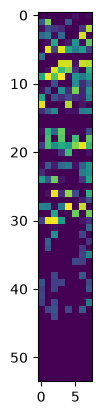

In [21]:
img, label = spike_mnist_test[10]

import matplotlib.pyplot as plt

%matplotlib inline

plt.imshow(img.sum(0)[0]);

In [22]:
img.sum(0)[0]

tensor([[  0.,   0.,   0.,   0.,   0.,   5.,   0.,   2.],
        [ 29.,  81.,   0.,   0.,  27.,   0.,   0.,   0.],
        [  5.,  24.,  16.,  11.,   0.,   0.,  16.,  88.],
        [ 34.,  43.,   3.,  34.,   0.,   0.,  93.,   0.],
        [  0.,   4.,  60.,   0.,   7.,  52.,   3.,  75.],
        [  0.,  95.,  20.,  96.,  59.,  42.,  55.,  18.],
        [ 35.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   1.,  93.,  93.,   5.,  92.,  89.],
        [  0.,   5.,  95.,  68.,  81.,  14.,   0.,  64.],
        [ 61., 100.,  73.,  99.,   3.,  53.,  40.,  56.],
        [  0.,   0.,  24.,   0.,   0.,  49.,  13.,  31.],
        [  4.,  25.,   0.,  49.,  13.,  79.,  10.,  52.],
        [ 59.,   0.,  25.,  12.,  22.,  12.,  10.,  46.],
        [ 96.,   0.,   0.,   0.,  88.,   0.,   6.,   0.],
        [ 12.,  29.,  48.,   1.,   5.,   4.,  42.,  46.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  4.,

In [25]:
def try_timestep():
    for timestep in range(100, 200):
        sinabs_model = from_model(
            ann, input_shape=input_shape, add_spiking_output=True, synops=False, num_timesteps=timestep
        )

        spike_mnist_test = CANDataset(
            windows_test, attack_onehot_test, train=False, is_spiking=True, time_window=timestep
        )

        spike_test_loader = DataLoader(
            spike_mnist_test, batch_size=test_batch_size, shuffle=True
        )

        correct_predictions = []

        for data, target in tqdm(spike_test_loader):
            data, target = data.to(device), target.to(device)


            data = sl.FlattenTime()(data)

            with torch.no_grad():
                output = sinabs_model(data)

                output = output.unflatten(
                    0,
                    (target.shape[0], output.shape[0] // target.shape[0])
                )

            # Sum spikes over time and predict class
            pred = output.sum(1).argmax(dim=1)

            # Compare predictions with targets
            correct_predictions.append(pred.eq(target))

            # Stop after ~300 samples if desired
            if sum(len(x) for x in correct_predictions) >= 300:
                break

        correct_predictions = torch.cat(correct_predictions)

        accuracy = correct_predictions.float().mean().item() * 100

        print(f"Timesteps: {timestep}, Classification accuracy: {accuracy:.2f}%")

In [24]:
try_timestep()

  0%|          | 29/72220 [00:00<06:14, 192.57it/s]


Timesteps: 1, Classification accuracy: 23.00%


  0%|          | 29/72220 [00:00<07:44, 155.50it/s]


Timesteps: 2, Classification accuracy: 17.33%


  0%|          | 29/72220 [00:00<08:14, 146.12it/s]


...

Timesteps: 98, Classification accuracy: 89.33%


  0%|          | 29/72220 [00:04<2:59:52,  6.69it/s]


Timesteps: 99, Classification accuracy: 91.33%


  0%|          | 29/72220 [00:04<2:50:38,  7.05it/s]

Timesteps: 100, Classification accuracy: 90.33%


In [26]:
try_timestep()

  0%|          | 29/72220 [00:04<2:52:57,  6.96it/s]


Timesteps: 100, Classification accuracy: 85.67%


  0%|          | 29/72220 [00:04<3:06:02,  6.47it/s]


Timesteps: 101, Classification accuracy: 87.33%


  0%|          | 29/72220 [00:04<3:22:57,  5.93it/s]


...

Timesteps: 189, Classification accuracy: 90.67%


  0%|          | 29/72220 [00:08<5:39:51,  3.54it/s]


Timesteps: 190, Classification accuracy: 87.33%


  0%|          | 21/72220 [00:06<5:59:48,  3.34it/s]


KeyboardInterrupt: 

In [ ]:
import sinabs.layers as sl
import torch
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

sinabs_model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in tqdm(spike_test_loader):

        data = data.to(device)
        target = target.to(device)

        # Flatten time and batch dimensions
        data = sl.FlattenTime()(data)

        output = sinabs_model(data)

        # Restore batch and time dimensions
        output = output.unflatten(
            0,
            (target.shape[0], output.shape[0] // target.shape[0])
        )

        # Sum spikes over time
        pred = output.sum(1).argmax(dim=1)

        all_preds.append(pred.cpu())
        all_targets.append(target.cpu())

# Concatenate all batches
y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_targets).numpy()

# -------------------------
# Metrics
# -------------------------

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted precision: {precision:.4f}")
print(f"Weighted recall: {recall:.4f}")
print(f"Weighted F1 score: {f1:.4f}")

# -------------------------
# Classification report
# -------------------------

class_names = ["R", "T"]       # Change if using 4 classes

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=2,
        zero_division=0,
    )
)

# -------------------------
# Confusion matrix
# -------------------------

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

print("\nConfusion matrix:")
print(cm_df)

# -------------------------
# False Positive / Negative Rates
# -------------------------

print("\nFalse positive rate per class:")
for i, cls in enumerate(class_names):
    fp = cm[:, i].sum() - cm[i, i]
    tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
    fpr = fp / (fp + tn) if (fp + tn) else 0
    print(f"  {cls}: {fpr:.4f}")

print("\nFalse negative rate per class:")
for i, cls in enumerate(class_names):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    fnr = fn / (fn + tp) if (fn + tp) else 0
    print(f"  {cls}: {fnr:.4f}")

100%|██████████| 55700/55700 [1:51:55<00:00,  8.29it/s]  


Accuracy: 0.9528
Weighted precision: 0.9524
Weighted recall: 0.9528
Weighted F1 score: 0.9524

Classification report:
              precision    recall  f1-score   support

           R       0.96      0.98      0.97    412496
           T       0.93      0.89      0.91    144502

    accuracy                           0.95    556998
   macro avg       0.94      0.93      0.94    556998
weighted avg       0.95      0.95      0.95    556998


Confusion matrix:
        R       T
R  402562    9934
T   16368  128134

False positive rate per class:
  R: 0.1133
  T: 0.0241

False negative rate per class:
  R: 0.0241
  T: 0.1133
